# 🤖 Fase 4 y 5: Modelado y Evaluación (CRISP-ML(Q))
En esta fase entrenaremos y evaluaremos modelos clasificadores para predecir el `RISK_LEVEL` basándonos en las variables socio-demográficas y clínicas.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Modelos clasificadores
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

sns.set_theme(style="whitegrid")

### 1. Cargar Datos y Separar Variables

In [2]:
df = pd.read_csv('cleaned_data.csv')
X = df.drop(columns=['RISK_LEVEL'])
y = df['RISK_LEVEL']

print("Variables predictoras (X):", list(X.columns))
print("Variable objetivo (y):", y.name)
y.value_counts()

Variables predictoras (X): ['Edad', 'Genero', 'Comunidad_Autonoma', 'Situacion_Laboral', 'Historial_Familiar', 'Estres_Diario', 'Horas_Sueno', 'Actividad_Fisica', 'Apoyo_Social', 'Consumo_Redes']
Variable objetivo (y): RISK_LEVEL


RISK_LEVEL
Medio    408
Bajo     396
Alto     396
Name: count, dtype: int64

### 2. División Entrenamiento / Test (80/20 Estratificado)
Estratificamos sobre `y` para conservar la proporción de clases.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape}, Test: {X_test.shape}")

Entrenamiento: (960, 10), Test: (240, 10)


### 3. Definición del Preprocesamiento
Utilizaremos `ColumnTransformer` para estandarizar variables numéricas y codificar variables categóricas con `OneHotEncoder`.

In [4]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Numéricas: ['Edad', 'Estres_Diario', 'Horas_Sueno', 'Apoyo_Social', 'Consumo_Redes']
Categóricas: ['Genero', 'Comunidad_Autonoma', 'Situacion_Laboral', 'Historial_Familiar', 'Actividad_Fisica']


### 4. Definición y Entrenamiento de Modelos
Entrenaremos Regresión Logística, Random Forest y Gradient Boosting.

In [5]:
models = {
    'LogisticRegression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'GradientBoosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ])
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} - Exactitud en Test: {acc:.4f}")

LogisticRegression - Exactitud en Test: 0.8708


RandomForest - Exactitud en Test: 0.7417


GradientBoosting - Exactitud en Test: 0.8250


### 5. Optimización de Hiperparámetros (Grid Search)
Optimizamos RandomForest, que suele ser muy robusto y estable.

In [6]:
rf_pipeline = models['RandomForest']

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)
print(f"Exactitud en CV del mejor modelo: {grid_search.best_score_:.4f}")

Mejores parámetros: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Exactitud en CV del mejor modelo: 0.7875


### 6. Evaluación Detallada del Mejor Modelo

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

        Alto       0.81      0.82      0.82        79
        Bajo       0.86      0.82      0.84        79
       Medio       0.67      0.68      0.67        82

    accuracy                           0.78       240
   macro avg       0.78      0.78      0.78       240
weighted avg       0.78      0.78      0.78       240



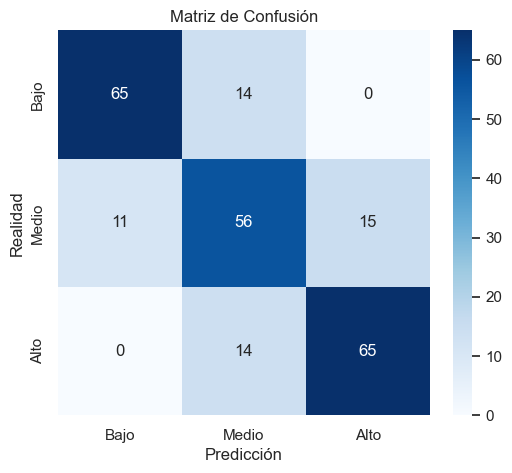

In [7]:
y_pred = best_model.predict(X_test)
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['Bajo', 'Medio', 'Alto'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bajo', 'Medio', 'Alto'], 
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.savefig('images/matriz_confusion.png', bbox_inches='tight')
plt.show()

### 7. Exportación de Artefactos
Guardamos el pipeline completo del mejor modelo y los nombres de las features originales en formato pickle.

In [8]:
# Guardamos el pipeline completo (incluye el preprocesamiento ColumnTransformer y el clasificador)
with open('modelo_salud_mental.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Guardamos los nombres de las columnas para reconstruir las predicciones de forma exacta en la UI
features = list(X.columns)
with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Artefactos guardados exitosamente como 'modelo_salud_mental.pkl' y 'features.pkl'")

Artefactos guardados exitosamente como 'modelo_salud_mental.pkl' y 'features.pkl'
